Name: Aman Shrestha\
Id: 2408222

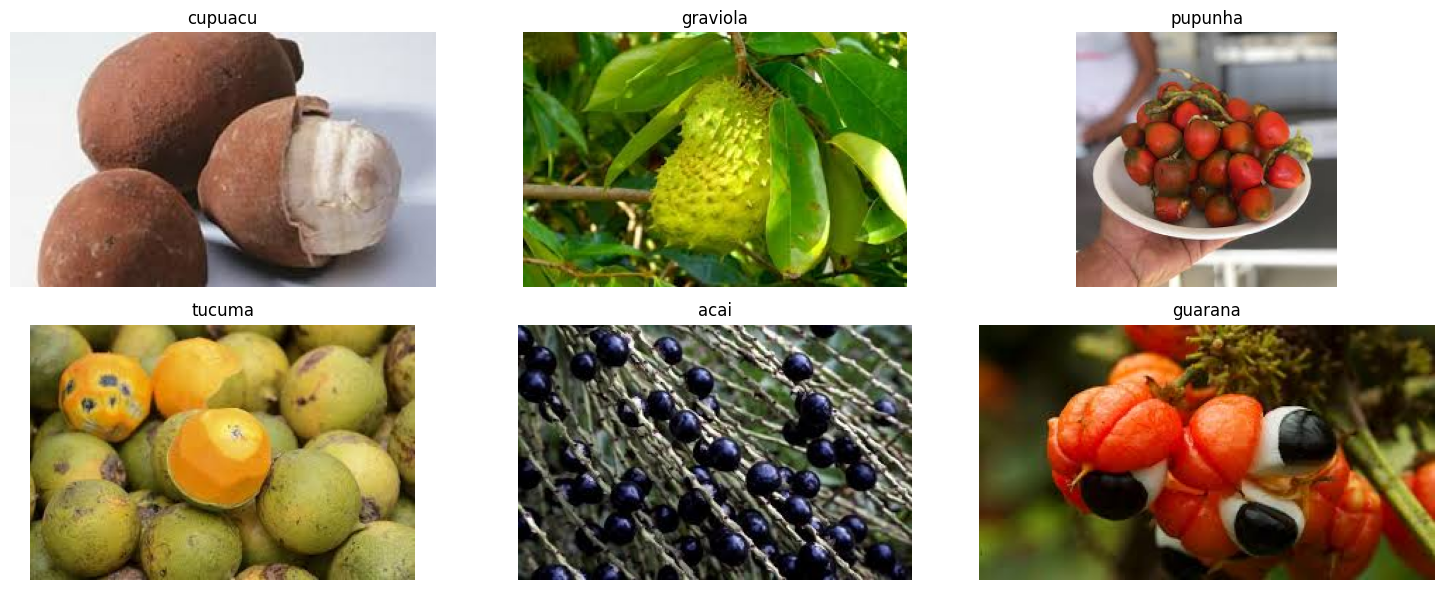

In [154]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Path to your dataset
train_dir = "/content/drive/MyDrive/Ai and machine learning/Week 5/FruitinAmazon/train"  # change this

# Step 1: Get class directories
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

images = []
titles = []

# Step 2: Select one random image from each class
for cls in classes:
    class_path = os.path.join(train_dir, cls)

    # Get all image files (filter common formats)
    img_files = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if img_files:
        img_name = random.choice(img_files)
        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path)
        images.append(img)
        titles.append(cls)

# Step 3: Plot images in grid (2 rows)
num_images = len(images)
cols = (num_images + 1) // 2  # divide into 2 rows

plt.figure(figsize=(15, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [155]:


corrupted_images = []

# Iterate through each class subdirectory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            # Try opening and verifying the image
            with Image.open(img_path) as img:
                img.verify()  # checks for corruption

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)

            # Remove corrupted image
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final report
if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


In [156]:
from tensorflow.keras import layers

data_augmentation_layers = [
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.1),
    layers.Rescaling(1./255),
]
def data_augmentation(images):
  for layer in data_augmentation_layers:
    images = layer(images)
  return images

In [157]:
import tensorflow as tf
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=True,
validation_split=validation_split,
subset='training',
seed=123
)
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=False,
validation_split=validation_split,
subset='validation',
seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [158]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Set number of classes
num_classes = 6

# Input shape
input_shape = (128, 128, 3)

model = models.Sequential([
layers.Input(shape=(128, 128, 3)),
*data_augmentation_layers, # Include augmentation before the model layers
layers.Conv2D(32, (3,3), activation=None),
layers.BatchNormalization(),
layers.Activation("relu"),
layers.MaxPooling2D(pool_size=(2,2), strides=2),
layers.Dropout(0.25),

layers.Conv2D(32, (3,3), activation=None),
layers.BatchNormalization(),
layers.Activation("relu"),
layers.MaxPooling2D(pool_size=(2,2), strides=2),
layers.Dropout(0.25),

layers.Flatten(),

layers.Dense(64, activation=None),
layers.BatchNormalization(),
layers.Activation("relu"),
layers.Dropout(0.25),

layers.Dense(128, activation=None),
layers.BatchNormalization(),
layers.Activation("relu"),
layers.Dropout(0.25),

#Output layer
layers.Dense(num_classes, activation="softmax")
]) # Initialize an empty Sequential model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_8 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_8               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_6 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_14 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 61, 61, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 61, 61, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,863,526 (7.11 MB)

 Trainable params: 1,863,014 (7.11 MB)

 Non-trainable params: 512 (2.00 KB)

In [159]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    # batch_size=16
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.1644 - loss: 2.2706


Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 889ms/step - accuracy: 0.1806 - loss: 2.1936 - val_accuracy: 0.8333 - val_loss: 1.7864
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.3657 - loss: 1.6364
Epoch 2: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 807ms/step - accuracy: 0.3472 - loss: 1.6600 - val_accuracy: 0.7222 - val_loss: 1.7748
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.3947 - loss: 1.5812
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4028 - loss: 1.5766 - val_accuracy: 0.0000e+00 - val_loss: 1.7760
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.4242 - loss: 1.3673
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 734ms/step - accuracy: 0.4444 - loss: 1.3272 - val_accuracy: 0.0000e+00 - val_loss: 1.7663
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.5399 - loss: 

In [160]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.0000e+00 - loss: 1.6657

Test Loss: 1.6657
Test Accuracy: 0.0000


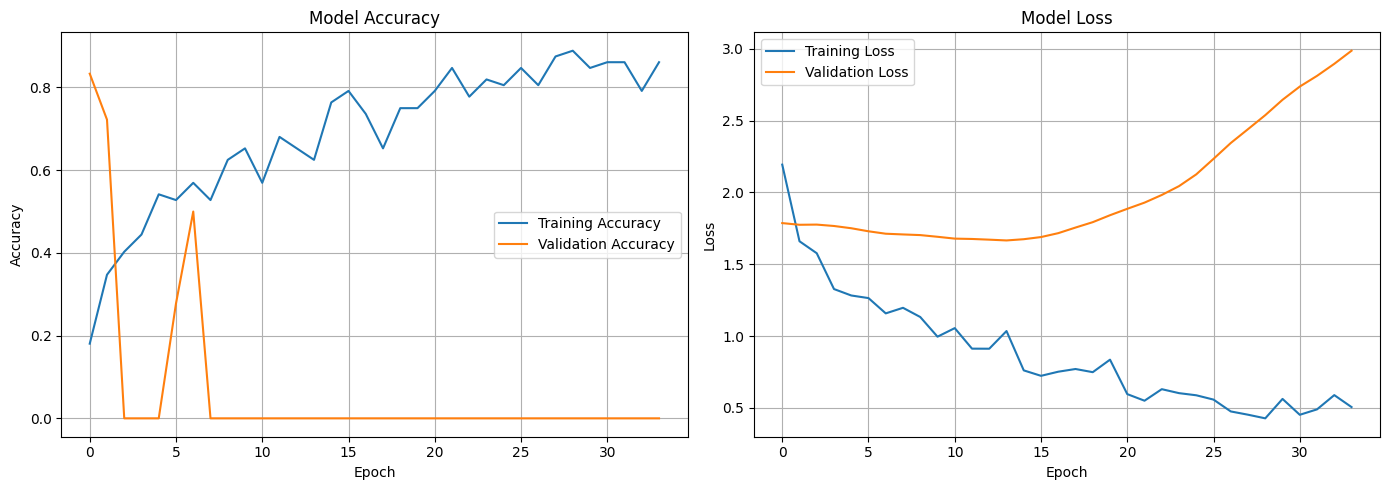

In [161]:
# Plot training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [162]:
# Task 6: Save and Load the Model
# Write your code here

# Save the model
model.save('fruit_classifier_cnn.h5')
print("Model saved to 'fruit_classifier_cnn.h5'")

# Load the saved model
loaded_model = tf.keras.models.load_model('fruit_classifier_cnn.h5')
print("Model loaded successfully.")

# Re-evaluate the loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(val_ds)
print(f"\nLoaded Model - Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_acc:.4f}")

Model saved to 'fruit_classifier_cnn.h5'


Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step - accuracy: 0.0000e+00 - loss: 1.6657

Loaded Model - Test Loss: 1.6657
Loaded Model - Test Accuracy: 0.0000


In [163]:
import tensorflow as tf

test_dir = "/content/drive/MyDrive/Ai and machine learning/Week 5/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=16,
    shuffle=False   # VERY IMPORTANT for correct evaluation
)

Found 30 files belonging to 6 classes.


In [164]:
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

In [165]:
import numpy as np

# Get predictions (probabilities)
predictions = model.predict(test_ds)

# Convert probabilities → class labels
pred_labels = np.argmax(predictions, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step


In [166]:
true_labels = []

for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

In [167]:
from sklearn.metrics import classification_report

class_names = classes # Use the 'classes' variable that was already extracted

print(classification_report(true_labels, pred_labels, target_names=class_names))

              precision    recall  f1-score   support

     cupuacu       0.00      0.00      0.00         5
    graviola       0.17      1.00      0.29         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5
        acai       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [168]:
from tensorflow.keras.applications import VGG16
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

In [169]:
for layer in base_model.layers:
  layer.trainable = False

In [170]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
# Add custom layers on top of the pre-trained model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image
x = Dense(1024, activation='relu')(x) # Fully connected layer with 1024 neurons
x = Dense(6, activation='softmax')(x) # Output layer for 10 classes (with softmax for multi-class classification)

In [171]:
from tensorflow.keras.models import Model
# Create the final model
model = Model(inputs=base_model.input, outputs=x)

In [172]:
from tensorflow.keras.optimizers import Adam
# Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
new_history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    # batch_size=16
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1493 - loss: 1.8840
Epoch 1: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 7s/step - accuracy: 0.1667 - loss: 1.8882 - val_accuracy: 0.2222 - val_loss: 1.8153
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3640 - loss: 1.5446
Epoch 2: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.3889 - loss: 1.5141 - val_accuracy: 0.3333 - val_loss: 1.6550
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4572 - loss: 1.2653
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.5278 - loss: 1.2348 - val_accuracy: 0.5556 - val_loss: 1.0532
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6302 - loss: 1.0636
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.6250 - loss: 1.0852 - val_accuracy: 0.6667 - val_loss: 0.8879
Epoch 5/250
3/3 


Epoch 12: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.9722 - loss: 0.3261 - val_accuracy: 0.8889 - val_loss: 0.5251
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9699 - loss: 0.3087
Epoch 13: val_accuracy improved from 0.88889 to 0.94444, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - accuracy: 0.9722 - loss: 0.2882 - val_accuracy: 0.9444 - val_loss: 0.4729
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9902 - loss: 0.2653
Epoch 14: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.9861 - loss: 0.2614 - val_accuracy: 0.9444 - val_loss: 0.4967
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9797 - loss: 0.2488
Epoch 15: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.9861 - loss: 0.2349 - val_accuracy: 0.8333 - val_loss: 0.5454
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9751 - loss: 0.2060
Epoch 16: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 7s/step - accuracy: 0.9722 - loss: 0.2036 - val_accuracy: 0.9444 - val_loss: 0.4853
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 1.0000 - loss: 0.1895
Epoch 17: 

In [173]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.9444 - loss: 0.2851

Test Loss: 0.2851
Test Accuracy: 0.9444


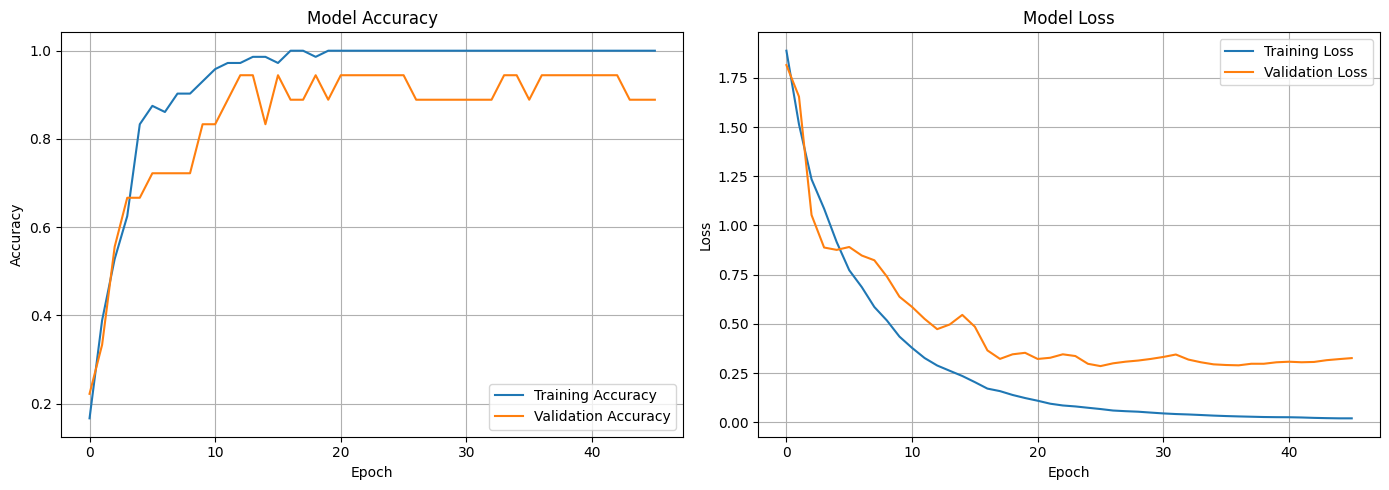

In [181]:
# Plot training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(new_history.history['accuracy'], label='Training Accuracy')
ax1.plot(new_history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(new_history.history['loss'], label='Training Loss')
ax2.plot(new_history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [175]:
# Task 6: Save and Load the Model
# Write your code here

# Save the model
model.save('fruit_classifier_cnn.h5')
print("Model saved to 'fruit_classifier_cnn.h5'")

# Load the saved model
loaded_model = tf.keras.models.load_model('fruit_classifier_cnn.h5')
print("Model loaded successfully.")

# Re-evaluate the loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(val_ds)
print(f"\nLoaded Model - Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_acc:.4f}")

Model saved to 'fruit_classifier_cnn.h5'


Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9444 - loss: 0.2851

Loaded Model - Test Loss: 0.2851
Loaded Model - Test Accuracy: 0.9444


In [176]:
import tensorflow as tf

test_dir = "/content/drive/MyDrive/Ai and machine learning/Week 5/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=16,
    shuffle=False   # VERY IMPORTANT for correct evaluation
)

Found 30 files belonging to 6 classes.


In [177]:
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

In [185]:
import numpy as np

# Get predictions (probabilities)
predictions = model.predict(test_ds)

# Convert probabilities → class labels
pred_labels = np.argmax(predictions, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step


In [186]:
true_labels = []

for images, labels in test_ds:
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

In [187]:
from sklearn.metrics import classification_report

class_names = classes # Use the 'classes' variable that was already extracted

print(classification_report(true_labels, pred_labels, target_names=class_names))

              precision    recall  f1-score   support

     cupuacu       0.60      0.60      0.60         5
    graviola       0.50      0.20      0.29         5
     pupunha       0.83      1.00      0.91         5
      tucuma       0.80      0.80      0.80         5
        acai       0.00      0.00      0.00         5
     guarana       0.30      0.60      0.40         5

    accuracy                           0.53        30
   macro avg       0.51      0.53      0.50        30
weighted avg       0.51      0.53      0.50        30

